Imports

In [328]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
from datetime import datetime
import warnings
import folium
from math import radians, sin, cos, sqrt, atan2
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn import tree
from sklearn.preprocessing import StandardScaler
warnings.simplefilter("ignore")
pd.set_option('display.max_columns', None)

Getting The Data

In [234]:
result_df = pd.read_csv('results.csv')
stats_df = pd.read_csv('status.csv')
drivers_df = pd.read_csv('drivers.csv')
races_df = pd.read_csv('races.csv')
constructor_df = pd.read_csv('constructors.csv')
driver_standings_df = pd.read_csv('driver_standings.csv')
pd.get_option("display.max_columns",None)

In [235]:
result_df.head() 

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [236]:
stats_df.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [237]:
stats_df.tail() 

,statusId,status
134,137,Damage
135,138,Debris
136,139,Illness
137,140,Undertray
138,141,Cooling system


In [238]:
drivers_df.head() 

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [239]:
drivers_df.tail() 

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
852,854,mick_schumacher,47,MSC,Mick,Schumacher,1999-03-22,German,http://en.wikipedia.org/wiki/Mick_Schumacher
853,855,zhou,24,ZHO,Guanyu,Zhou,1999-05-30,Chinese,http://en.wikipedia.org/wiki/Zhou_Guanyu
854,856,de_vries,21,DEV,Nyck,de Vries,1995-02-06,Dutch,http://en.wikipedia.org/wiki/Nyck_de_Vries
855,857,piastri,81,PIA,Oscar,Piastri,2001-04-06,Australian,http://en.wikipedia.org/wiki/Oscar_Piastri
856,858,sargeant,2,SAR,Logan,Sargeant,2000-12-31,American,http://en.wikipedia.org/wiki/Logan_Sargeant


In [240]:
races_df.head() 

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [241]:
races_df.tail()  

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
1096,1116,2023,18,69,United States Grand Prix,2023-10-22,19:00:00,https://en.wikipedia.org/wiki/2023_United_Stat...,2023-10-20,17:30:00,2023-10-21,18:00:00,\N,\N,2023-10-20,21:00:00,2023-10-21,22:00:00
1097,1117,2023,19,32,Mexico City Grand Prix,2023-10-29,20:00:00,https://en.wikipedia.org/wiki/2023_Mexico_City...,2023-10-27,18:30:00,2023-10-27,22:00:00,2023-10-28,17:30:00,2023-10-28,21:00:00,\N,\N
1098,1118,2023,20,18,São Paulo Grand Prix,2023-11-05,17:00:00,https://en.wikipedia.org/wiki/2023_S%C3%A3o_Pa...,2023-11-03,14:30:00,2023-11-04,14:30:00,\N,\N,2023-11-03,18:00:00,2023-11-04,18:30:00
1099,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,06:00:00,https://en.wikipedia.org/wiki/2023_Las_Vegas_G...,2023-11-17,04:30:00,2023-11-17,08:00:00,2023-11-18,04:30:00,2023-11-18,08:00:00,\N,\N
1100,1120,2023,22,24,Abu Dhabi Grand Prix,2023-11-26,13:00:00,https://en.wikipedia.org/wiki/2023_Abu_Dhabi_G...,2023-11-24,09:30:00,2023-11-24,13:00:00,2023-11-25,10:30:00,2023-11-25,14:00:00,\N,\N


In [242]:
constructor_df.head() 

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [243]:
constructor_df.tail() 

,constructorId,constructorRef,name,nationality,url
206,209,manor,Manor Marussia,British,http://en.wikipedia.org/wiki/Manor_Motorsport
207,210,haas,Haas F1 Team,American,http://en.wikipedia.org/wiki/Haas_F1_Team
208,211,racing_point,Racing Point,British,http://en.wikipedia.org/wiki/Racing_Point_F1_Team
209,213,alphatauri,AlphaTauri,Italian,http://en.wikipedia.org/wiki/Scuderia_AlphaTauri
210,214,alpine,Alpine F1 Team,French,http://en.wikipedia.org/wiki/Alpine_F1_Team


In [244]:
driver_standings_df.head() 

,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


In [245]:
driver_standings_df.tail() 

,driverStandingsId,raceId,driverId,points,position,positionText,wins
34119,72183,1110,846,69.0,8,8,0
34120,72184,1110,839,35.0,10,10,0
34121,72185,1110,844,99.0,5,5,0
34122,72186,1110,857,34.0,11,11,0
34123,72187,1110,817,0.0,21,21,0


Merge DataFrames To One 

In [246]:
# Test describe() to races dataframe
races_df.describe()

,raceId,year,round,circuitId
count,1101.000000,1101.000000,1101.000000,1101.000000
mean,553.355132,1992.020890,8.494096,23.700272
std,321.425790,20.296406,5.081089,19.346014
min,1.000000,1950.000000,1.000000,1.000000
25%,276.000000,1976.000000,4.000000,9.000000
50%,551.000000,1994.000000,8.000000,18.000000
75%,826.000000,2010.000000,12.000000,34.000000
max,1120.000000,2023.000000,22.000000,80.000000


In [247]:
# Float64 will not work too well with the dataframe merge, convert value to int!
races_df = races_df.raceId.astype(int)

# Start de merging!
con1 = pd.merge(result_df, races_df, on ='raceId')
con2 = pd.merge(con1, drivers_df, on = 'driverId')
con3 = pd.merge(con2, driver_standings_df, on = 'driverId')
con4 = pd.merge(con3, constructor_df, on ='constructorId')
df = pd.merge(con4, stats_df, on ='statusId')
pd.get_option("display.max_columns",None)
df.head()

,resultId,raceId_x,driverId,constructorId,number_x,grid,position_x,positionText_x,positionOrder,points_x,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,driverRef,number_y,code,forename,surname,dob,nationality_x,url_x,driverStandingsId,raceId_y,points_y,position_y,positionText_y,wins,constructorRef,name,nationality_y,url_y,status
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,18,10.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
1,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,9,19,14.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
2,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,27,20,14.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
3,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,48,21,20.0,2,2,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
4,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,69,22,28.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished


Modifications before calculations/evaluation methods 

In [248]:
# Remove unnecessary column
df = df.drop('position_x', axis=1)

In [249]:
# Adding a new column which contains the full name of drivers
df['driver_name'] = df['forename']+' '+df['surname']
df.head()

,resultId,raceId_x,driverId,constructorId,number_x,grid,positionText_x,positionOrder,points_x,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,driverRef,number_y,code,forename,surname,dob,nationality_x,url_x,driverStandingsId,raceId_y,points_y,position_y,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name
0,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,18,10.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
1,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,9,19,14.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
2,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,27,20,14.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
3,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,48,21,20.0,2,2,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
4,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,69,22,28.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton


In [250]:
# Convert datatype from string to date
df['dob'] = pd.to_datetime(df['dob'])
pd.to_datetime(df.dob)

0         1985-01-07
1         1985-01-07
2         1985-01-07
3         1985-01-07
4         1985-01-07
             ...    
3537622   1913-05-05
3537623   1913-05-05
3537624   1913-05-05
3537625   1913-05-05
3537626   1913-05-05
Name: dob, Length: 3537627, dtype: datetime64[ns]

In [251]:
df['dob'] = pd.to_datetime(df['dob'])

In [252]:
# Rename
col_name = {'number_x':'number','milliseconds':'timetaken_in_millisec','fastestLapSpeed':'max_speed',
 'name_x':'grand_prix','number_y':'driver_num','code':'driver_code','nationality_x':'nationality','name_y':'company',
 'raceId_x':'racerId','points_x':'points','position_y':'position'}

df.rename(columns=col_name,inplace=True)
df.head()

,resultId,racerId,driverId,constructorId,number,grid,positionText_x,positionOrder,points,laps,time,timetaken_in_millisec,fastestLap,rank,fastestLapTime,max_speed,statusId,driverRef,driver_num,driver_code,forename,surname,dob,nationality,url_x,driverStandingsId,raceId_y,points_y,position,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name
0,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,18,10.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
1,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,9,19,14.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
2,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,27,20,14.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
3,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,48,21,20.0,2,2,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
4,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,69,22,28.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton


Calculations before using "Describe" function

In [253]:
# Calculating driver age, put it to new column
dates = datetime.today()-df['dob']
age = dates.dt.days/365
df['age'] = round(age)
df.head()

,resultId,racerId,driverId,constructorId,number,grid,positionText_x,positionOrder,points,laps,time,timetaken_in_millisec,fastestLap,rank,fastestLapTime,max_speed,statusId,driverRef,driver_num,driver_code,forename,surname,dob,nationality,url_x,driverStandingsId,raceId_y,points_y,position,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name,age
0,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,18,10.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
1,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,9,19,14.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
2,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,27,20,14.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
3,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,48,21,20.0,2,2,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
4,1,18,1,1,22,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,69,22,28.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0


In [254]:
# changing datatype

l = ['number','timetaken_in_millisec','fastestLap','rank','max_speed','driver_num']
for i in l:
    df[i] = pd.to_numeric(df[i],errors='coerce')


In [255]:
# drop an unnecessary column
df = df.drop('driver_num', axis=1)

In [256]:
# seperating categorical and numerical columns for understading 

cat = []
num = []
for i in df.columns:
    if df[i].dtypes == 'O':
        cat.append(i)
    else:
        num.append(i)
df[cat].head()

,positionText_x,time,fastestLapTime,driverRef,driver_code,forename,surname,nationality,url_x,positionText_y,constructorRef,name,nationality_y,url_y,status,driver_name
0,1,1:34:50.616,1:27.452,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
1,1,1:34:50.616,1:27.452,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
2,1,1:34:50.616,1:27.452,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,3,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
3,1,1:34:50.616,1:27.452,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,2,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton
4,1,1:34:50.616,1:27.452,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,3,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton


In [257]:
df.head()

,resultId,racerId,driverId,constructorId,number,grid,positionText_x,positionOrder,points,laps,time,timetaken_in_millisec,fastestLap,rank,fastestLapTime,max_speed,statusId,driverRef,driver_code,forename,surname,dob,nationality,url_x,driverStandingsId,raceId_y,points_y,position,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name,age
0,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,1,hamilton,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,18,10.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
1,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,1,hamilton,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,9,19,14.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
2,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,1,hamilton,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,27,20,14.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
3,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,1,hamilton,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,48,21,20.0,2,2,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
4,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,1,hamilton,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,69,22,28.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0


In [258]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
resultId,3537627.0,12630.091396,1.0,5125.0,11763.0,21140.0,26085.0,8209.508032
racerId,3537627.0,517.06657,1.0,234.0,467.0,856.0,1110.0,331.536193
driverId,3537627.0,204.182795,1.0,20.0,105.0,229.0,858.0,265.852299
constructorId,3537627.0,39.412151,1.0,6.0,16.0,37.0,214.0,56.860468
number,3537467.0,15.419845,0.0,6.0,12.0,21.0,208.0,13.997199
grid,3537627.0,9.763203,0.0,4.0,9.0,15.0,34.0,6.557031
positionOrder,3537627.0,11.229562,1.0,5.0,10.0,17.0,39.0,7.378775
points,3537627.0,2.998598,0.0,0.0,0.0,4.0,50.0,5.334331
laps,3537627.0,48.36204,0.0,32.0,55.0,67.0,200.0,25.123229
timetaken_in_millisec,1364748.0,5955319.302289,207071.0,5356627.0,5707207.0,6184300.0,15090540.0,1224894.729306


In [294]:
df.isna()

,resultId,racerId,driverId,constructorId,number,grid,positionText_x,positionOrder,points,laps,time,timetaken_in_millisec,fastestLap,rank,fastestLapTime,max_speed,driverRef,driver_code,forename,surname,nationality,url_x,driverStandingsId,raceId_y,points_y,position,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name,age
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363488,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1363489,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1363490,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1363491,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


MAPS!!!!

In [259]:
circuit_df = pd.read_csv('circuits.csv')
circuit_df.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [260]:
# Plotting circuits in the world map
coordinates = []
for lat, lng in zip(circuit_df['lat'], circuit_df['lng']):
    coordinates.append([lat, lng])

maps = folium.Map(zoom_start=10, tiles='OpenStreetMap')  
for i, j in zip(coordinates, circuit_df.name):
    marker = folium.Marker(
        location=i,
        icon=folium.Icon(icon="car", color='cadetblue', prefix='fa'),
        popup="<strong>{0}</strong>".format(j))
    marker.add_to(maps)

maps

In [288]:
# Calculating average distance between all circuits

def haversine(lat1, lon1, lat2, lon2):
    # Convert all to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Formula
    dslat = lat2 - lat1
    dslon = lon2 - lon1
    a = sin(dslat / 2)**2 + cos(lat1) * cos(lat2) * sin(dslon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = 6371 * c  # Radius of the Earth in km

    return distance

# Calculate distances between circuit locations
distances = []
for i in range(len(coordinates)):
    for j in range(i + 1, len(coordinates)):
        lat1, lon1 = coordinates[i]
        lat2, lon2 = coordinates[j]
        distance = haversine(lat1, lon1, lat2, lon2)
        distances.append(distance)

# Calculate average distance
average_distance = sum(distances) / len(distances)
print(f"Average Distance between Circuits: {average_distance:.2f} km")

Average Distance between Circuits: 6535.24 km


Data Filtration 

In [261]:
# Drop some unnecessary columns for easier reading
df = df.drop('statusId', axis=1)
df = df.drop('dob', axis=1)

# Making dataframe for who finished the races successfully 
df_fin = df[df['status'] == 'Finished']
df_fin.tail()

,resultId,racerId,driverId,constructorId,number,grid,positionText_x,positionOrder,points,laps,time,timetaken_in_millisec,fastestLap,rank,fastestLapTime,max_speed,driverRef,driver_code,forename,surname,nationality,url_x,driverStandingsId,raceId_y,points_y,position,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name,age
1363657,23346,967,839,209,31.0,22,12,12,0.0,71,+45.809,10907144.0,47.0,16.0,1:27.796,176.686,ocon,OCO,Esteban,Ocon,French,http://en.wikipedia.org/wiki/Esteban_Ocon,72083,1106,29.0,9,9,0,manor,Manor Marussia,British,http://en.wikipedia.org/wiki/Manor_Motorsport,Finished,Esteban Ocon,27.0
1363658,23346,967,839,209,31.0,22,12,12,0.0,71,+45.809,10907144.0,47.0,16.0,1:27.796,176.686,ocon,OCO,Esteban,Ocon,French,http://en.wikipedia.org/wiki/Esteban_Ocon,72123,1107,31.0,9,9,0,manor,Manor Marussia,British,http://en.wikipedia.org/wiki/Manor_Motorsport,Finished,Esteban Ocon,27.0
1363659,23346,967,839,209,31.0,22,12,12,0.0,71,+45.809,10907144.0,47.0,16.0,1:27.796,176.686,ocon,OCO,Esteban,Ocon,French,http://en.wikipedia.org/wiki/Esteban_Ocon,72143,1108,31.0,10,10,0,manor,Manor Marussia,British,http://en.wikipedia.org/wiki/Manor_Motorsport,Finished,Esteban Ocon,27.0
1363660,23346,967,839,209,31.0,22,12,12,0.0,71,+45.809,10907144.0,47.0,16.0,1:27.796,176.686,ocon,OCO,Esteban,Ocon,French,http://en.wikipedia.org/wiki/Esteban_Ocon,72163,1109,31.0,10,10,0,manor,Manor Marussia,British,http://en.wikipedia.org/wiki/Manor_Motorsport,Finished,Esteban Ocon,27.0
1363661,23346,967,839,209,31.0,22,12,12,0.0,71,+45.809,10907144.0,47.0,16.0,1:27.796,176.686,ocon,OCO,Esteban,Ocon,French,http://en.wikipedia.org/wiki/Esteban_Ocon,72184,1110,35.0,10,10,0,manor,Manor Marussia,British,http://en.wikipedia.org/wiki/Manor_Motorsport,Finished,Esteban Ocon,27.0


In [262]:
meanMS = df.max_speed.mean() # Mean for top speed of racers
meanFL = df.fastestLap.mean() # Mean for top lap times of racers
df = df_fin[df_fin['max_speed']>meanMS] # Filter rows where "max_speed"is above the dataset's mean "max speed"
df.head()

,resultId,racerId,driverId,constructorId,number,grid,positionText_x,positionOrder,points,laps,time,timetaken_in_millisec,fastestLap,rank,fastestLapTime,max_speed,driverRef,driver_code,forename,surname,nationality,url_x,driverStandingsId,raceId_y,points_y,position,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name,age
0,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,18,10.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
1,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,9,19,14.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
2,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,27,20,14.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
3,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,48,21,20.0,2,2,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
4,1,18,1,1,22.0,1,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.3,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,69,22,28.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0


In [263]:
df[df['fastestLap']>meanFL] # Filter rows where 'fastestLap' values exceed the mean lap time in the dataset

,resultId,racerId,driverId,constructorId,number,grid,positionText_x,positionOrder,points,laps,time,timetaken_in_millisec,fastestLap,rank,fastestLapTime,max_speed,driverRef,driver_code,forename,surname,nationality,url_x,driverStandingsId,raceId_y,points_y,position,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name,age
322,27,19,1,1,22.0,9,5,5,4.0,56,+46.548,5525103.0,53.0,3.0,1:35.462,209.033,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,1,18,10.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
323,27,19,1,1,22.0,9,5,5,4.0,56,+46.548,5525103.0,53.0,3.0,1:35.462,209.033,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,9,19,14.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
324,27,19,1,1,22.0,9,5,5,4.0,56,+46.548,5525103.0,53.0,3.0,1:35.462,209.033,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,27,20,14.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
325,27,19,1,1,22.0,9,5,5,4.0,56,+46.548,5525103.0,53.0,3.0,1:35.462,209.033,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,48,21,20.0,2,2,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
326,27,19,1,1,22.0,9,5,5,4.0,56,+46.548,5525103.0,53.0,3.0,1:35.462,209.033,hamilton,HAM,Lewis,Hamilton,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,69,22,28.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,Lewis Hamilton,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363488,26042,1108,856,213,21.0,18,17,17,0.0,52,+33.128,5150066.0,48.0,18.0,1:32.353,229.636,de_vries,DEV,Nyck,de Vries,Dutch,http://en.wikipedia.org/wiki/Nyck_de_Vries,72079,1106,0.0,19,19,0,alphatauri,AlphaTauri,Italian,http://en.wikipedia.org/wiki/Scuderia_AlphaTauri,Finished,Nyck de Vries,29.0
1363489,26042,1108,856,213,21.0,18,17,17,0.0,52,+33.128,5150066.0,48.0,18.0,1:32.353,229.636,de_vries,DEV,Nyck,de Vries,Dutch,http://en.wikipedia.org/wiki/Nyck_de_Vries,72119,1107,0.0,20,20,0,alphatauri,AlphaTauri,Italian,http://en.wikipedia.org/wiki/Scuderia_AlphaTauri,Finished,Nyck de Vries,29.0
1363490,26042,1108,856,213,21.0,18,17,17,0.0,52,+33.128,5150066.0,48.0,18.0,1:32.353,229.636,de_vries,DEV,Nyck,de Vries,Dutch,http://en.wikipedia.org/wiki/Nyck_de_Vries,72139,1108,0.0,20,20,0,alphatauri,AlphaTauri,Italian,http://en.wikipedia.org/wiki/Scuderia_AlphaTauri,Finished,Nyck de Vries,29.0
1363491,26042,1108,856,213,21.0,18,17,17,0.0,52,+33.128,5150066.0,48.0,18.0,1:32.353,229.636,de_vries,DEV,Nyck,de Vries,Dutch,http://en.wikipedia.org/wiki/Nyck_de_Vries,72159,1109,0.0,20,20,0,alphatauri,AlphaTauri,Italian,http://en.wikipedia.org/wiki/Scuderia_AlphaTauri,Finished,Nyck de Vries,29.0


In [264]:
df = df[df['age']<df['age'].mean()] # Filter rows where 'age' values exceed the mean age in the dataset
df.head()
dfbackup = df # Store this same thing, for later on

Skewness

In [265]:
dfnumbers = df.select_dtypes(include='number') # Show only numbers
dfnumbers.skew() #Skew

resultId                -3.025620
racerId                 -2.452885
driverId                -0.264964
constructorId            0.788574
number                   1.058673
grid                     0.810450
positionOrder            0.743670
points                   0.396979
laps                     0.530968
timetaken_in_millisec    3.042205
fastestLap              -0.408728
rank                     0.733204
max_speed                0.580202
driverStandingsId       -3.119151
raceId_y                -2.283631
points_y                 1.396858
position                 0.732489
wins                     2.481812
age                     -0.718223
dtype: float64

Outlier Treatment

In [266]:
# Outlier Removal [Removing values too high or too low to get a futher understanding of data later on]

Q1 = dfnumbers.quantile(0.25)
Q3 = dfnumbers.quantile(0.75)
IQR = Q3 - Q1
dfnumbers = dfnumbers[~((dfnumbers<(Q1-1.5*IQR)) | (dfnumbers>(Q3+1.5*IQR))).any(axis=1)]
dfnumbers.head()

,resultId,racerId,driverId,constructorId,number,grid,positionOrder,points,laps,timetaken_in_millisec,fastestLap,rank,max_speed,driverStandingsId,raceId_y,points_y,position,wins,age
17407,20780,841,1,1,3.0,2,2,18.0,58,5392556.0,41.0,8.0,211.382,68157,969,18.0,2,0,39.0
17459,20780,841,1,1,3.0,2,2,18.0,58,5392556.0,41.0,8.0,211.382,64385,842,22.0,3,0,39.0
17460,20780,841,1,1,3.0,2,2,18.0,58,5392556.0,41.0,8.0,211.382,64691,841,18.0,2,0,39.0
17461,20780,841,1,1,3.0,2,2,18.0,58,5392556.0,41.0,8.0,211.382,64409,843,47.0,2,1,39.0
17462,20780,841,1,1,3.0,2,2,18.0,58,5392556.0,41.0,8.0,211.382,64433,844,59.0,2,1,39.0


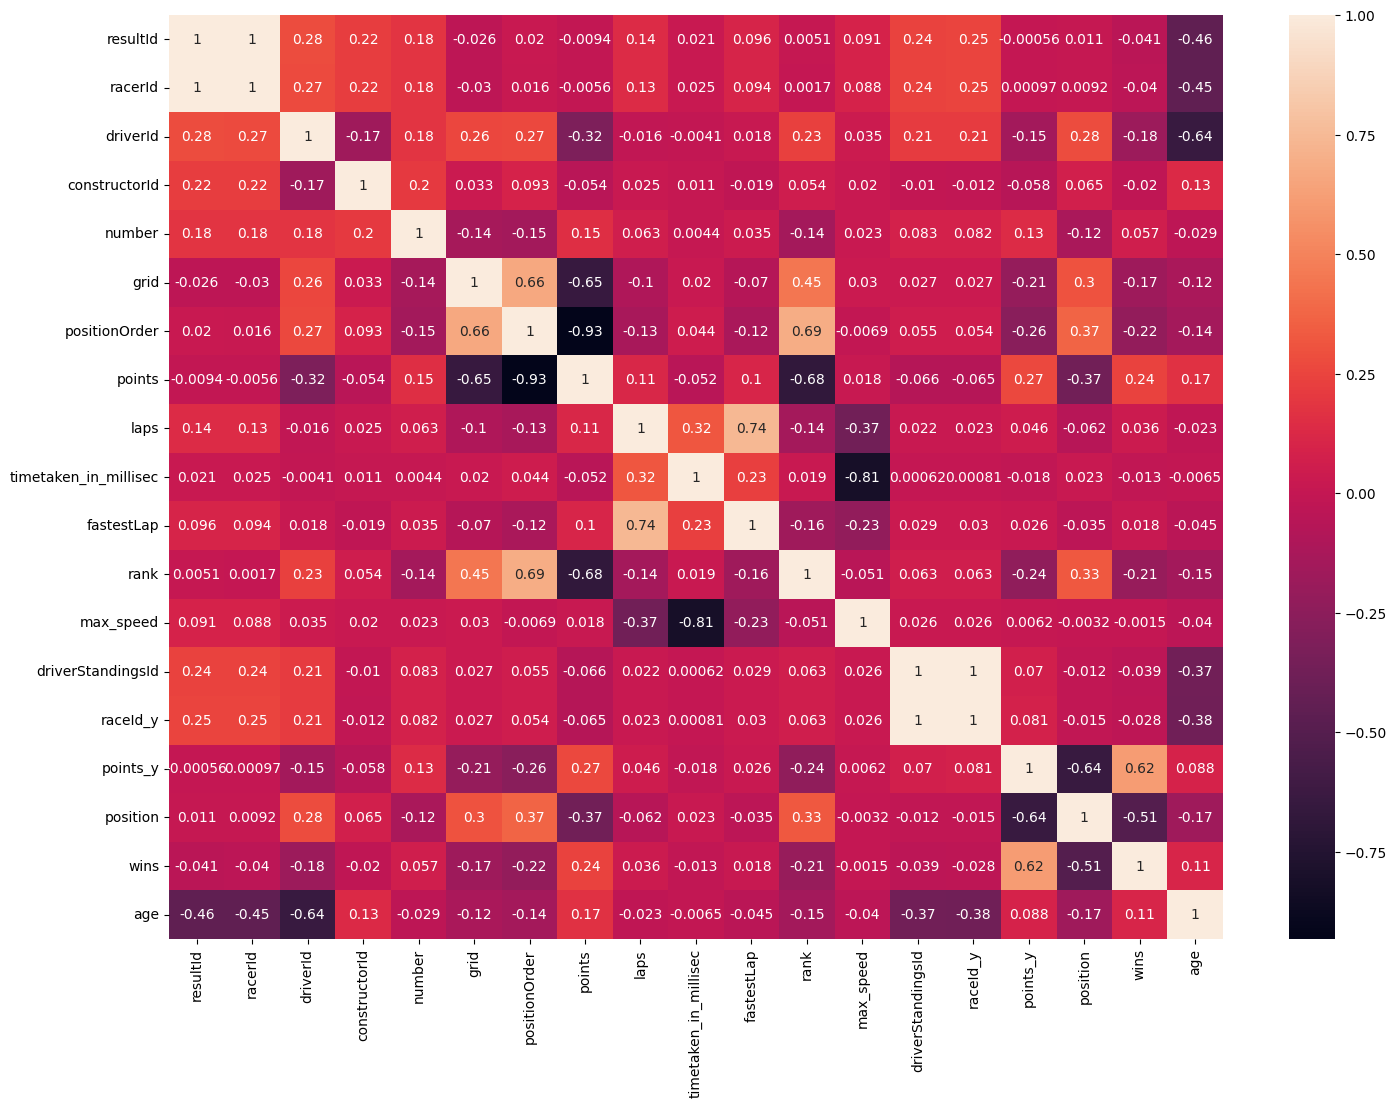

In [289]:
# Heatmap
plt.figure(figsize=(17,12)) # Figure sizing
sns.heatmap(dfnumbers.corr(),annot=True) # For heatmap
plt.show() # Show plot

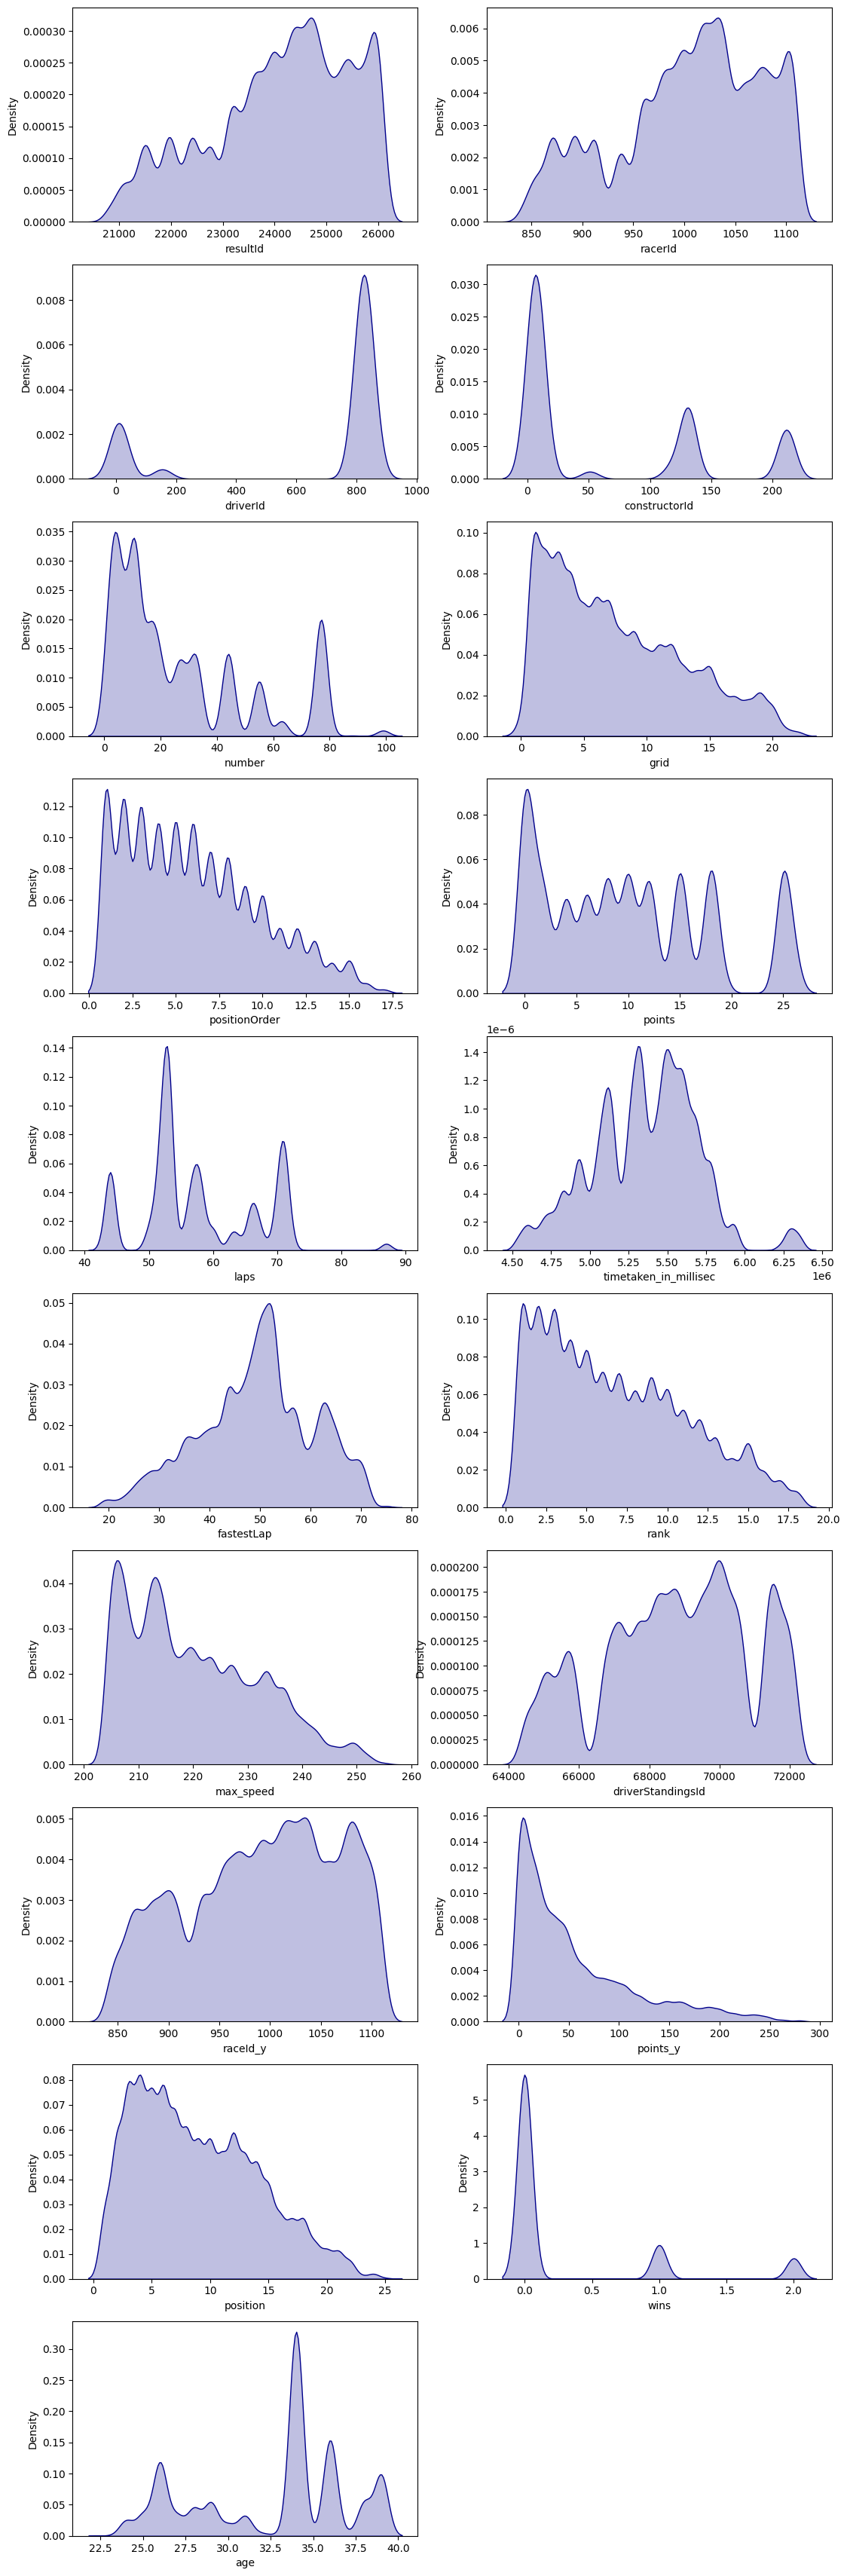

In [268]:
# KDE (Kernel Density Estimation) plot for checking normalization 

num.remove('statusId') # to prevent an error
num.remove('dob') # to prevent an error 

plt.figure(figsize=(13,48)) 
for i,j in zip(num,range(1,len(num)+1)): # Some formula for making the figure
    plt.subplot(11,2,j) # Sizing
    sns.kdeplot(dfnumbers[i],shade=True,color='darkblue') 
plt.show() # Show plot

Skewing after Outlier Treatment

In [269]:
dfnumbers.skew() 

resultId                -0.518770
racerId                 -0.485089
driverId                -1.255906
constructorId            0.873808
number                   1.044271
grid                     0.640612
positionOrder            0.591585
points                   0.480956
laps                     0.507295
timetaken_in_millisec   -0.000935
fastestLap              -0.230591
rank                     0.539837
max_speed                0.582029
driverStandingsId       -0.262024
raceId_y                -0.270493
points_y                 1.365005
position                 0.528504
wins                     1.935658
age                     -0.424835
dtype: float64

Encoding, in preparation for Machine Learning Algorithms

In [270]:
le = LabelEncoder() # Store the function in variable
for i in cat: # loop, to make it as a dataframe
    df[i] = le.fit_transform(df[i])
df.head()

,resultId,racerId,driverId,constructorId,number,grid,positionText_x,positionOrder,points,laps,time,timetaken_in_millisec,fastestLap,rank,fastestLapTime,max_speed,driverRef,driver_code,forename,surname,nationality,url_x,driverStandingsId,raceId_y,points_y,position,positionText_y,wins,constructorRef,name,nationality_y,url_y,status,driver_name,age
0,1,18,1,1,22.0,1,0,1,10.0,58,1332,5690616.0,39.0,2.0,536,218.3,15,16,23,13,4,24,1,18,10.0,1,0,1,11,11,2,8,0,25,39.0
1,1,18,1,1,22.0,1,0,1,10.0,58,1332,5690616.0,39.0,2.0,536,218.3,15,16,23,13,4,24,9,19,14.0,1,0,1,11,11,2,8,0,25,39.0
2,1,18,1,1,22.0,1,0,1,10.0,58,1332,5690616.0,39.0,2.0,536,218.3,15,16,23,13,4,24,27,20,14.0,3,20,1,11,11,2,8,0,25,39.0
3,1,18,1,1,22.0,1,0,1,10.0,58,1332,5690616.0,39.0,2.0,536,218.3,15,16,23,13,4,24,48,21,20.0,2,11,1,11,11,2,8,0,25,39.0
4,1,18,1,1,22.0,1,0,1,10.0,58,1332,5690616.0,39.0,2.0,536,218.3,15,16,23,13,4,24,69,22,28.0,3,20,1,11,11,2,8,0,25,39.0


ML Algorithms!!!

In [271]:
x = df.drop(['driver_name'], axis=1) # for ml
y = df.driver_name # for ml
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.3,random_state=42) # tain test split formula... 
clf = DecisionTreeClassifier(max_depth=5,random_state=2004) # setting
clf.fit(xtrain, ytrain) 

DecisionTreeClassifier(max_depth=5, random_state=2004)

Decision Tree Workflow

In [272]:
tree.export_text(clf) # to some kind of text format

'|--- feature_2 <= 2.00\n|   |--- class: 25\n|--- feature_2 >  2.00\n|   |--- feature_17 <= 47.50\n|   |   |--- feature_18 <= 43.50\n|   |   |   |--- feature_21 <= 44.50\n|   |   |   |   |--- feature_20 <= 1.50\n|   |   |   |   |   |--- class: 6\n|   |   |   |   |--- feature_20 >  1.50\n|   |   |   |   |   |--- class: 29\n|   |   |   |--- feature_21 >  44.50\n|   |   |   |   |--- feature_18 <= 41.50\n|   |   |   |   |   |--- class: 45\n|   |   |   |   |--- feature_18 >  41.50\n|   |   |   |   |   |--- class: 46\n|   |   |--- feature_18 >  43.50\n|   |   |   |--- feature_19 <= 16.00\n|   |   |   |   |--- class: 48\n|   |   |   |--- feature_19 >  16.00\n|   |   |   |   |--- feature_17 <= 38.50\n|   |   |   |   |   |--- class: 49\n|   |   |   |   |--- feature_17 >  38.50\n|   |   |   |   |   |--- class: 50\n|   |--- feature_17 >  47.50\n|   |   |--- feature_21 <= 46.50\n|   |   |   |--- class: 43\n|   |   |--- feature_21 >  46.50\n|   |   |   |--- class: 13\n'

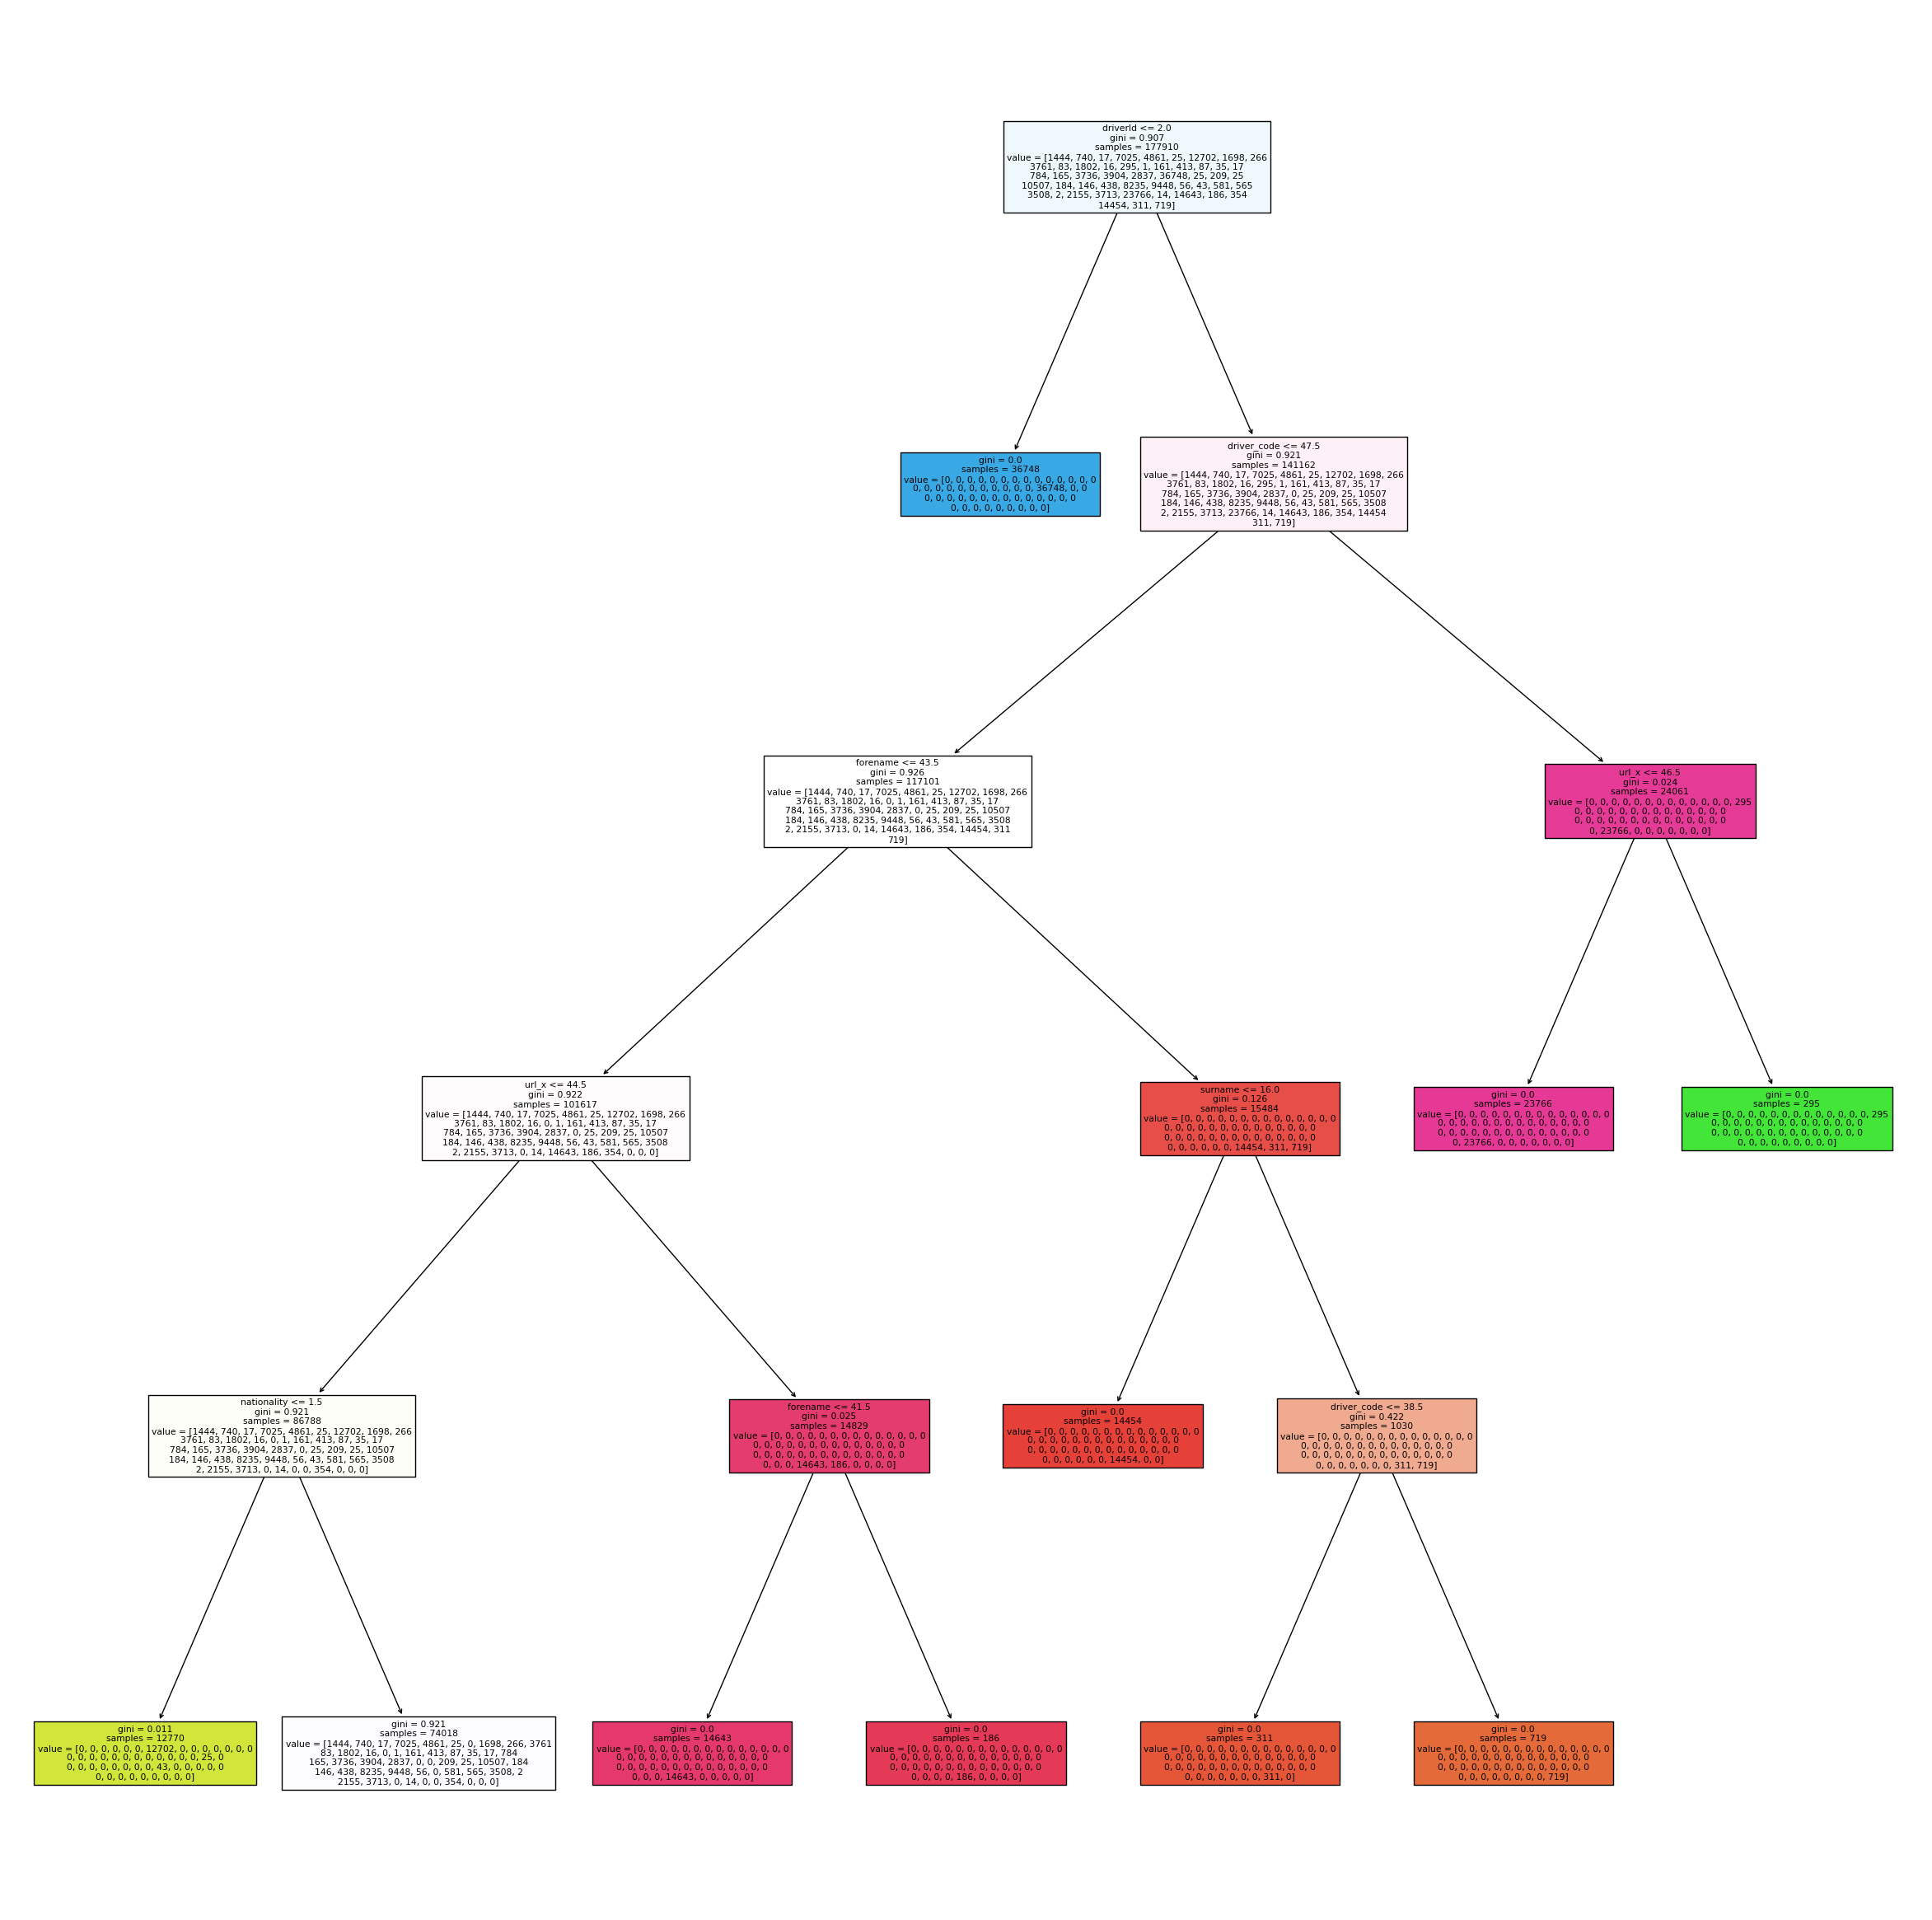

In [273]:
# appropriate variables for the decision tree
fn = list(df.columns)
fn.remove('driver_name') # dont need the driver name for this one

# Plotting decision tree
dtplot = plt.figure(figsize=(30,30))
_ = tree.plot_tree(clf,
               feature_names=fn,
               filled=True)

Data Modeling using Classification Machine Learning Algorithms

In [274]:
# de hard part?
lr = LogisticRegression(solver='sag')
dtc = DecisionTreeClassifier()
rfc = RandomForestClassifier()
knn = KNeighborsClassifier()
gnb = GaussianNB()
sgdc = SGDClassifier()

li = [lr,sgdc,knn,gnb,rfc,dtc] # Store in a list
d = {} #emoty array
for i in li: # loop for training
    # Formula for finding some sort of accuracy
    i.fit(xtrain,ytrain) 
    ypred = i.predict(xtest) 
    print(i,":",accuracy_score(ypred,ytest)*100)
    d.update({str(i):i.score(xtest,ytest)*100})

LogisticRegression(solver='sag') : 20.728412548525863
SGDClassifier() : 20.43725737068513
KNeighborsClassifier() : 99.87409505823103
GaussianNB() : 74.48457664463331
RandomForestClassifier() : 100.0
DecisionTreeClassifier() : 100.0


MinMaxScalar

In [276]:
norm = MinMaxScaler().fit(xtrain) # Use MMS on training data, store in a variable
X_train_norm = norm.transform(xtrain)# transform de training data
X_test_norm = norm.transform(xtest) # transform de testing data

#same as before, store in array, create empty array, loop formula for accuracy
li = [lr,sgdc,knn,gnb,rfc,dtc] 
di = {}
for i in li:
    i.fit(X_train_norm,ytrain)
    ypred = i.predict(X_test_norm)
    print(i,":",accuracy_score(ypred,ytest)*100)
    di.update({str(i):i.score(X_test_norm,ytest)*100})

LogisticRegression(solver='sag') : 99.9816388626587
SGDClassifier() : 98.72652397439933
KNeighborsClassifier() : 99.99606547056972
GaussianNB() : 100.0
RandomForestClassifier() : 100.0
DecisionTreeClassifier() : 100.0


Stadndard Scaler

In [278]:
std = StandardScaler().fit(xtrain) # Use SS on training data, store in a variable
# same drill
x_train_std = std.transform(xtrain)
x_test_std = std.transform(xtest)

li = [lr,sgdc,knn,gnb,rfc,dtc]
dic = {}
for i in li:
    i.fit(x_train_std,ytrain)
    ypred = i.predict(x_test_std)
    print(i,":",accuracy_score(ypred,ytest)*100)
    dic.update({str(i):i.score(x_test_std,ytest)*100})

LogisticRegression(solver='sag') : 100.0
SGDClassifier() : 99.14489560381912
KNeighborsClassifier() : 99.9986884901899
GaussianNB() : 100.0
RandomForestClassifier() : 100.0
DecisionTreeClassifier() : 100.0


Robust Scalar

In [291]:
scaler = RobustScaler().fit(xtrain)  # Use RS on training data, store in a variable
# same drill
xtrain_scaled = scaler.transform(xtrain)
xtest_scaled = scaler.transform(xtest)
li = [lr,sgdc,knn,gnb,rfc,dtc]
dics = {}
for i in li:
    i.fit(xtrain_scaled,ytrain)
    ypred = i.predict(xtest_scaled)
    print(i,":",accuracy_score(ypred,ytest)*100)
    dics.update({str(i):i.score(xtest_scaled,ytest)*100})

LogisticRegression(solver='sag') : 100.0
SGDClassifier() : 98.99800650508865
KNeighborsClassifier() : 99.99737698037981
GaussianNB() : 100.0
RandomForestClassifier() : 100.0
DecisionTreeClassifier() : 100.0


Cross Validation 

In [354]:
# Load the Iris dataset (replace with your actual dataset)
iris = load_iris()
x, y = iris.data, iris.target

# store classifiers in a variable
classifiers = {
    'Logistic Regression': LogisticRegression(solver='sag'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'Stochastic Gradient Descent': SGDClassifier()
}

# store scalers in a variable
scalers = {
    'No Scaling': None,
    'MinMax Scaler': MinMaxScaler(),
    'Robust Scaler': RobustScaler(),
    'Standard Scaler': StandardScaler()
}

#  for-looping each classifier and scaler combination
for clf_name, clf in classifiers.items():
    for scaler_name, scaler in scalers.items():
        if scaler is None:
            model = clf  # end
        else:
            model = make_pipeline(scaler, clf) # bridge em up

        # cross-validate
        cv_scores = cross_val_score(model, x, y, cv=5)
        mean_accuracy = cv_scores.mean()

        # print de results
        print(f"{clf_name} with {scaler_name}: Mean Accuracy = {mean_accuracy:.4f}")

Logistic Regression with No Scaling: Mean Accuracy = 0.9800
Logistic Regression with MinMax Scaler: Mean Accuracy = 0.9267
Logistic Regression with Robust Scaler: Mean Accuracy = 0.9333
Logistic Regression with Standard Scaler: Mean Accuracy = 0.9600
Decision Tree with No Scaling: Mean Accuracy = 0.9600
Decision Tree with MinMax Scaler: Mean Accuracy = 0.9600
Decision Tree with Robust Scaler: Mean Accuracy = 0.9600
Decision Tree with Standard Scaler: Mean Accuracy = 0.9600
Random Forest with No Scaling: Mean Accuracy = 0.9667
Random Forest with MinMax Scaler: Mean Accuracy = 0.9600
Random Forest with Robust Scaler: Mean Accuracy = 0.9600
Random Forest with Standard Scaler: Mean Accuracy = 0.9667
K-Nearest Neighbors with No Scaling: Mean Accuracy = 0.9733
K-Nearest Neighbors with MinMax Scaler: Mean Accuracy = 0.9600
K-Nearest Neighbors with Robust Scaler: Mean Accuracy = 0.9333
K-Nearest Neighbors with Standard Scaler: Mean Accuracy = 0.9600
Gaussian Naive Bayes with No Scaling: Mean A

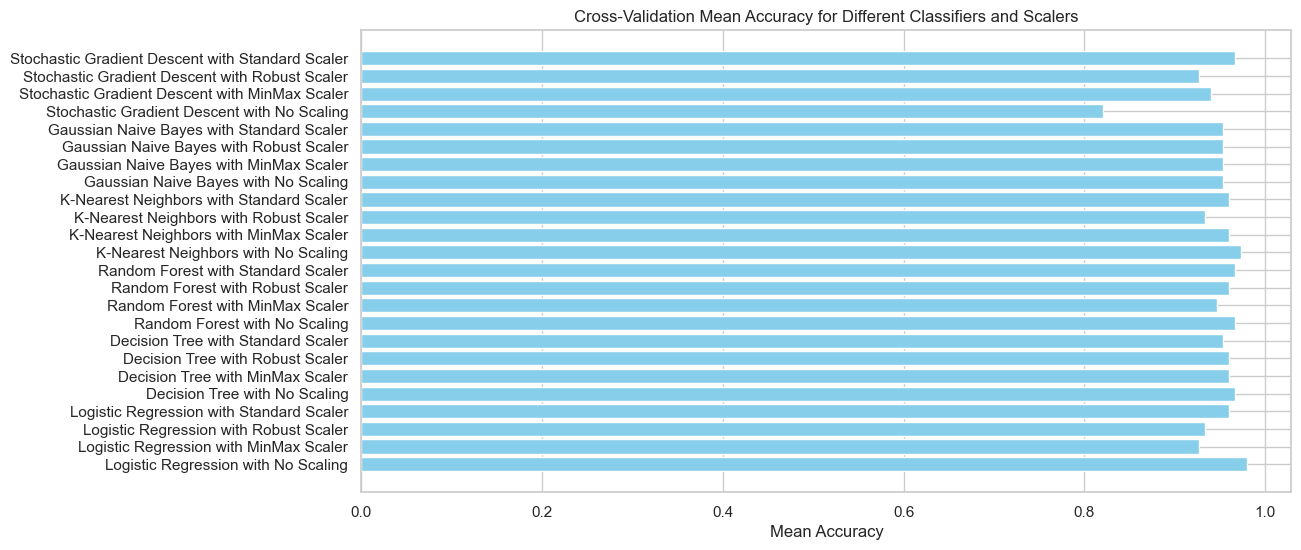

In [355]:
# load iris 
iris = load_iris()
x, y = iris.data, iris.target

# store classifiers in variable
classifiers = {
    'Logistic Regression': LogisticRegression(solver='sag'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'Stochastic Gradient Descent': SGDClassifier()
}

# store scalers in variable
scalers = {
    'No Scaling': None,
    'MinMax Scaler': MinMaxScaler(),
    'Robust Scaler': RobustScaler(),
    'Standard Scaler': StandardScaler()
}

#  lists to store data to plotting
labels = []
values = []

# loop classifier and scalar
for clf_name, clf in classifiers.items():
    for scaler_name, scaler in scalers.items():
        if scaler is None:
            model = clf
        else:
            model = make_pipeline(scaler, clf)

        # cross-validate
        cv_scores = cross_val_score(model, x, y, cv=5)
        mean_accuracy = cv_scores.mean()

        # add data for plotting
        labels.append(f"{clf_name} with {scaler_name}")
        values.append(mean_accuracy)

# Plot dem
plt.figure(figsize=(12, 6))
plt.barh(labels, values, color='skyblue')
plt.xlabel('Mean Accuracy')
plt.title('Cross-Validation Mean Accuracy for Different Classifiers and Scalers')
plt.show()

Confusion Matrix 

In [340]:
print("RANDOM FOREST\n\n\n\n")
rfc.fit(xtrain, ytrain) # Shove it in

# make predictions
y_pred = clf.predict(xtest)

#  classification report method!!
report = classification_report(ytest, y_pred)

# print em
print(report)

RANDOM FOREST




              precision    recall  f1-score   support

           0       1.00      1.00      1.00       572
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00      2950
           4       1.00      1.00      1.00      2039
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00      5316
           7       1.00      1.00      1.00       759
           8       1.00      1.00      1.00        88
           9       1.00      1.00      1.00      1651
          10       1.00      1.00      1.00        37
          11       1.00      1.00      1.00       736
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00       113
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00        69
          16       1.00      1.00      1.00       167
         

In [342]:
print("K-NEAREST NEIGHBOURS\n\n\n\n")
knn.fit(xtrain, ytrain) # Shove it in

# make predictions
y_pred = knn.predict(xtest)

#  classification report method!!
report = classification_report(ytest, y_pred)

# print em
print(report)

K-NEAREST NEIGHBOURS




              precision    recall  f1-score   support

           0       1.00      1.00      1.00       572
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00      2950
           4       1.00      1.00      1.00      2039
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00      5316
           7       1.00      1.00      1.00       759
           8       1.00      1.00      1.00        88
           9       1.00      1.00      1.00      1651
          10       1.00      1.00      1.00        37
          11       1.00      1.00      1.00       736
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00       113
          14       0.00      0.00      0.00         1
          15       0.99      0.97      0.98        69
          16       1.00      1.00      1.00       167
  

In [344]:
print("Stochastic Gradient Descent Classifier\n\n\n\n")
sgdc.fit(xtrain, ytrain) # Shove it in

# make predictions
y_pred = sgdc.predict(xtest)

#  classification report method!!
report = classification_report(ytest, y_pred)

# print em
print(report)

Stochastic Gradient Descent Classifier




              precision    recall  f1-score   support

           0       0.00      0.00      0.00       572
           1       0.00      0.00      0.00       300
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00      2950
           4       0.00      0.00      0.00      2039
           5       0.00      0.00      0.00        14
           6       0.00      0.00      0.00      5316
           7       0.00      0.00      0.00       759
           8       0.00      0.00      0.00        88
           9       0.00      0.00      0.00      1651
          10       0.00      0.00      0.00        37
          11       0.00      0.00      0.00       736
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00       113
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00        69
          16       0.00      0.00     

In [345]:
print("Gaussian Naive Bayes\n\n\n\n")
gnb.fit(xtrain, ytrain) # Shove it in

# make predictions
y_pred = gnb.predict(xtest)

#  classification report method!!
report = classification_report(ytest, y_pred)

# print em
print(report)

Gaussian Naive Bayes




              precision    recall  f1-score   support

           0       0.97      0.75      0.85       572
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00         8
           3       0.83      0.81      0.82      2950
           4       0.53      0.87      0.66      2039
           5       1.00      1.00      1.00        14
           6       0.76      0.70      0.73      5316
           7       0.69      0.18      0.29       759
           8       0.28      0.65      0.40        88
           9       0.77      0.28      0.41      1651
          10       0.14      1.00      0.25        37
          11       0.93      0.74      0.83       736
          12       1.00      1.00      1.00         3
          13       0.58      0.98      0.73       113
          14       1.00      1.00      1.00         1
          15       0.54      0.93      0.68        69
          16       0.25      0.99      0.40       167
  

In [350]:
print("Logistic Regression\n\n\n\n")
lr.fit(xtrain, ytrain) # Shove it in

# make predictions
y_pred = lr.predict(xtest)

#  classification report method!!
report = classification_report(ytest, y_pred)

# print em
print(report)

Logistic Regression




              precision    recall  f1-score   support

           0       0.00      0.00      0.00       572
           1       0.00      0.00      0.00       300
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00      2950
           4       0.00      0.00      0.00      2039
           5       0.00      0.00      0.00        14
           6       0.00      0.00      0.00      5316
           7       0.00      0.00      0.00       759
           8       0.00      0.00      0.00        88
           9       0.00      0.00      0.00      1651
          10       0.00      0.00      0.00        37
          11       0.00      0.00      0.00       736
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00       113
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00        69
          16       0.00      0.00      0.00       167
   